# Proyecto TELECOM

## Plan de trabajo

### 1.- Identificación del problema de negocio

**Contexto del sector**

El sector de la telecomunicaciones, en específico, aquel que brinda servicio como internet y telefonía a las personas es un mercado altamente saturado y competitivo, en el cual existen diversas opciones para el consumidor con lo cual sin muchas fronteras de salida estos pueden obtar por mejores opciones ya sea en términos monetarios, acccesibilidad o comodidad respecto a su opción actual (Jain & Surana, 2017).

Algo conocido en cualquier sector de productos y servicios que adquirir un nuevo cliente, sobre todo en casos de suscripción recurrente es de 5 a 25 veces más costoso que conservar uno ya existente (Gallo, 2014), siendo aún más importante en mercados tan saturados como es el caso de las empresas de telecomunicaciones como lo es caso de estudio aquí presentado.

Debido a lo anterior, es imperativo diseñar estrategias no solo de mercadeo más efectivas para convencer de su permanencia al cliente sino además detectar a tiempo los potenciales casos de pérdida permitiría enfocar los esfuerzos en ofrecer opciones y/o cambios que permitan la permanencia del consumidor con la finalidad de no derrochar recurso extras (que se traducen en más gastos y por lo tanto menos ganancias) en clientes cuya lealtad al servicio no está en vilo. 

Por ello este proyecto se enfocará en untilizar las bases de datos de los clientes de la empresa servicios telefónicos y de internet con la finalidad de detectar aquellos clientes que potencialmente tienen más probabilidades de cancelar sus servicios, con lo cual no solo se detectarían sectores de clientes en los cuales enfocar acciones que contraresten este riesgo (por ejemrplo con rebajas y/o promociones) sino además identificar si tienen un perfil o perfiles en común con lo cual el área de mercadeo podría desarrollar estrategias de retención más específicas y personalizadas que mejoren la posibilidades de conservar al consumidor de manera efectiva.



* Referencias:
    * Gallo, A. (2014). The value of keeping the right customers. Harvard business review, 29(10), 304-309.
    * Jain, P., & Surana, K. (2017). Reducing churn in telecom through advanced analytics. McKinsey & Company.  

### 2.- Descripción de los datos

#### Importar librerías y datos

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cargar los 4 archivos
df_contract = pd.read_csv("data/contract.csv")
df_personal = pd.read_csv("data/personal.csv")
df_internet = pd.read_csv("data/internet.csv")
df_phone = pd.read_csv("data/phone.csv")

# Unificar usando customerID tomando como base el archivo de información personal
df_final = df_contract.merge(df_personal, on="customerID", how="left")
df_final = df_final.merge(df_internet, on="customerID", how="left")
df_final = df_final.merge(df_phone, on="customerID", how="left")


#Creación de la columna de interés Churn basado en sí hay fecha de término de contrato
df_final['Churn'] = (df_final['EndDate'] != 'No').astype(int)


#### Información de los conjuntos de datos independientes y el unificado

In [3]:
df_personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [4]:
df_contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


In [5]:
df_phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


In [6]:
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


#### Detalle del volumen de datos

In [7]:
df_final.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,...,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines,Churn
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,...,No,DSL,No,Yes,No,No,No,No,NaN,0
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,...,No,DSL,Yes,No,Yes,No,No,No,No,0
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,...,No,DSL,Yes,Yes,No,No,No,No,No,1
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,...,No,DSL,Yes,No,Yes,Yes,No,No,NaN,0
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,...,No,Fiber optic,No,No,No,No,No,No,No,1


In [8]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   5517 non-null   object 
 13  OnlineSecurity    5517 non-null   object 
 14  OnlineBackup      5517 non-null   object 
 15  DeviceProtection  5517 non-null   object 
 16  TechSupport       5517 non-null   object 


Como se observa todos los casos de los conjuntos de datos individuales se conservan en el conjunto final debido al LEFT JOIN, siendo algunas columnas relacionadas a los servicios de telefonía e internet los que tienen datos faltantes respecto al número de clientes debido a que no todos ellos tienen los dos servicios contratados.

#### Nivel de calidad de los datos

In [9]:
print('Número de datos faltantes:')
print(df_final.isnull().sum())
print()
print('Número de entradas duplicadas:')
print(df_final.duplicated().sum())
print()
print('Número de customerIDs repetidos:')
print(len(df_final[df_final.duplicated(subset=['customerID'], keep=False)]))

Número de datos faltantes:
customerID             0
BeginDate              0
EndDate                0
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
Churn                  0
dtype: int64

Número de entradas duplicadas:
0

Número de customerIDs repetidos:
0


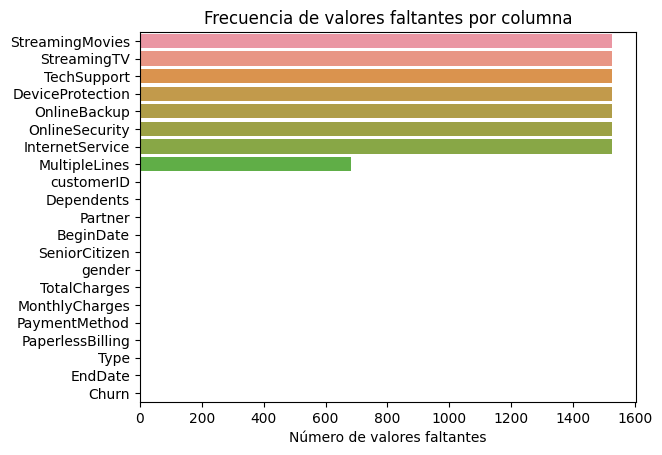

In [10]:
#Conteo de valores faltantes por columna
missing_counts = df_final.isna().sum()
top_missing = missing_counts.sort_values(ascending=False)
#Graficar 
sns.barplot(x=missing_counts.sort_values(ascending=False).values, y=missing_counts.sort_values(ascending=False).index)
plt.xlabel('Número de valores faltantes')
plt.title('Frecuencia de valores faltantes por columna')
plt.show()

Número de casos por Churn (Permanecencia / Cancelación)
0    5174
1    1869
Name: Churn, dtype: int64

Proporción de casos por Churn (Permanecencia / Cancelación)
0    0.73463
1    0.26537
Name: Churn, dtype: float64


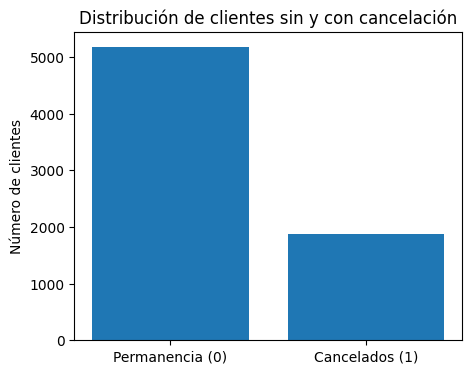

In [11]:
# Conteos y proporciones
print('Número de casos por Churn (Permanecencia / Cancelación)')
print(df_final['Churn'].value_counts())
print()
print('Proporción de casos por Churn (Permanecencia / Cancelación)')
print(df_final['Churn'].value_counts(normalize=True))

#Gráfico de barras
counts = df_final['Churn'].value_counts().sort_index()
labels = ['Permanencia (0)', 'Cancelados (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values)
plt.title('Distribución de clientes sin y con cancelación')
plt.ylabel('Número de clientes')
plt.show()

Como se observa no hay entradas duplicadas, ni IDs de clientes repetidos y los datos faltantes se deben a que no todos los cleintes tienen los dos servicios ofrecidos por la empresa. Respecto a datos con formato incorrecto serían las columna "BeginDate" y "EndDate" que sería pasarlas a forma DateTime en lugar de Object y la columna "TotalCharges" a float64 en lugar de object.

Algo que también puede modificarse son las columnas de "Dependents" y las últimas 7 del conjunto final, debido a que son variables binarias y en lugar de ser Object podrían ser Int64.

Otro cambio sería crear la columna "Churn" (tal y como ya se hizo en este EDA) para utilizarla como variable objetivo, creada a aprtir de los clientes que tienen una fecha de cancelación. Como se observa en el gráfico correspondiente hay un desbalance de clases, donde de los 7043 casos totales, un 73 % son casos de permanencia y el restante 27 % de casos de cancelaciones, esto deberá tomarse en cuenta al momento de la división de los datos para el entrenamiento del modelo predictivo.

#### Resumen estadístico

In [12]:
# Corrección de tipo de dato inicial para poder calcular las métricas
df_final['TotalCharges'] = pd.to_numeric(df_final['TotalCharges'], errors='coerce').fillna(0)


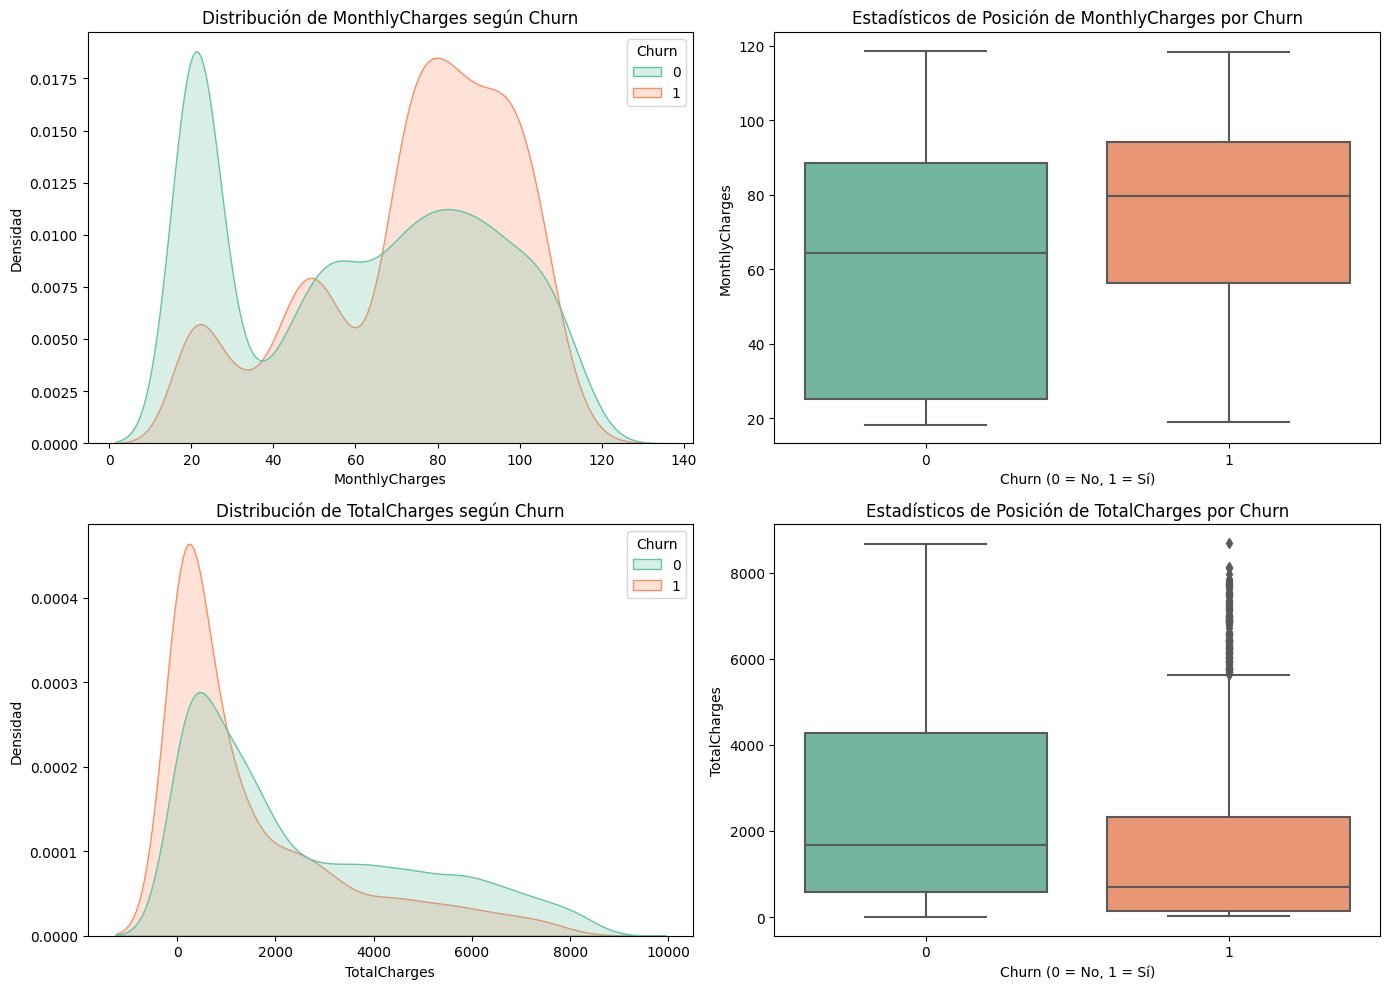

In [13]:
#Columnas númericas a evaluar
num_cols = ['MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#Creación de los gráficos de distribución y de caja por cada columna númerica
for i, col in enumerate(num_cols):  
    sns.kdeplot(data=df_final, x=col, hue='Churn', fill=True, common_norm=False, palette='Set2', ax=axes[i, 0])
    axes[i, 0].set_title(f'Distribución de {col} según Churn')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Densidad')
    
    sns.boxplot(data=df_final, x='Churn', y=col, palette='Set2', ax=axes[i, 1])
    axes[i, 1].set_title(f'Estadísticos de Posición de {col} por Churn')
    axes[i, 1].set_xlabel('Churn (0 = No, 1 = Sí)')
    axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.show()


Como se observa en la gráficas de distribución (izquierda), el monto total de cargos a los clientes son similares sin importar si pertenecen al grupo de clientes con permanencia o que cancelaron, sin embargo, respecto a los montos mensuales de cada cliente estos sí muestran una ligera diferencia, se logra observar que los clientes que permanencen (Churn = 0) tienen un marcado pico de frecuencia alrededor de los  20 USD de pago mensual, mientras que los que cancelaron tienen un pico más prominente alrededor de 80 USD, con lo que se puede teorizar que clientes que suelen pagar menos mensualemnte es más probable que permanenzcan con los servicios contratados en constraste con clientes que pagan mucho más (casi 4 veces más). Algo a mencionar es que los montos totales entre ambos grupos parece similar, por lo que no se trata solamente del costo total para el tiempo de contrato lo que define si un usuario cancela, sino la distribución d eeste monto en pagos más pequeños.

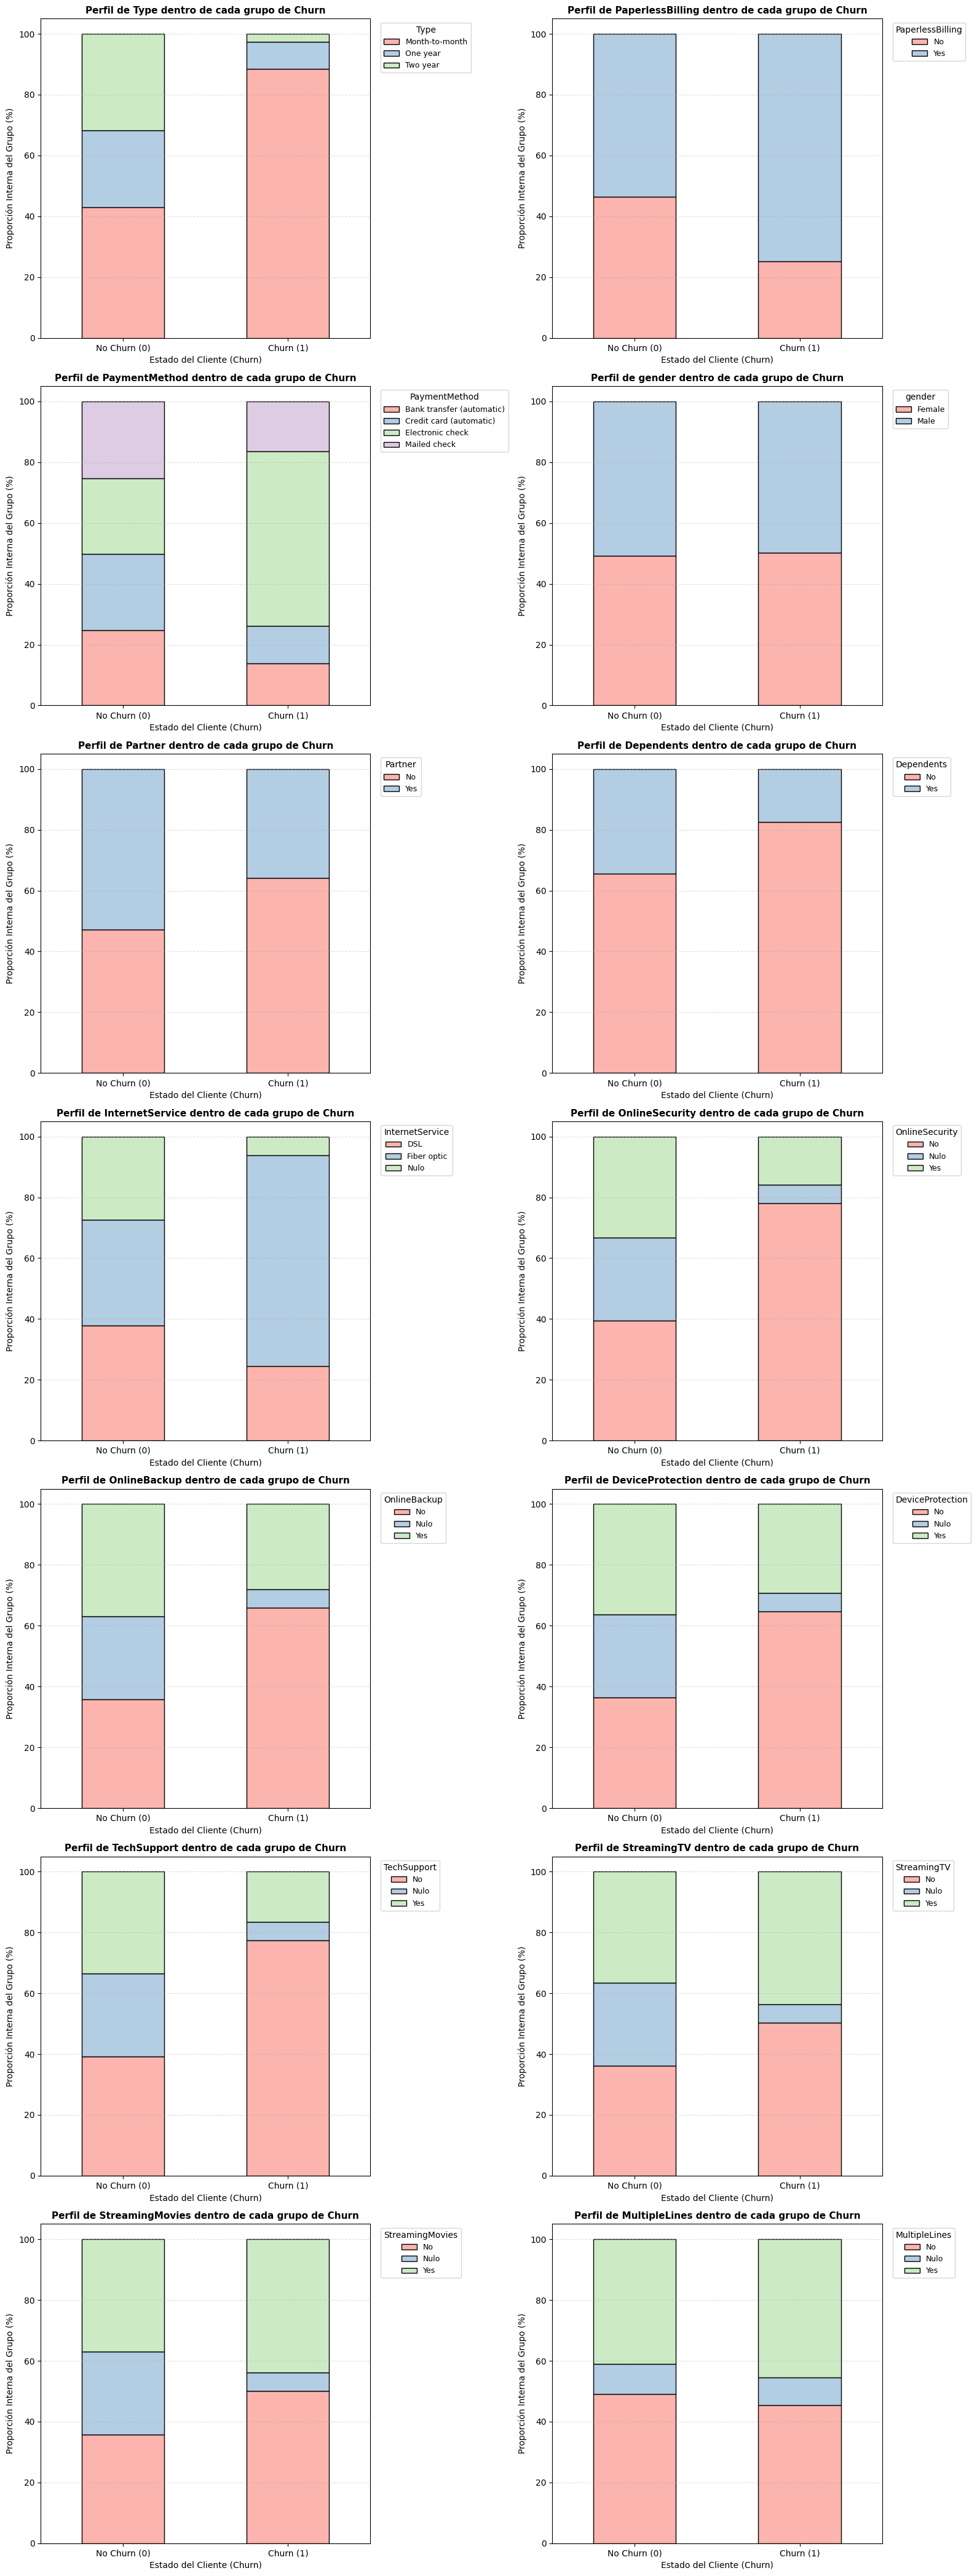

In [14]:
#Columnas a ignorar
columnas_ignorar = ['customerID', 'BeginDate', 'EndDate']

#Identificar variables categóricas 
cat_cols = [col for col in df_final.select_dtypes(include=['object']).columns if col not in columnas_ignorar]


n_cols = 2
n_rows = int(np.ceil(len(cat_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows))
axes = axes.flatten()


palette = sns.color_palette("Pastel1", 10)

#Generar el gráfico comparativo para cada variable con sus valores normalizados respecto a Churn para visualizar las proporciones de cada valor único de cada columna categorica en cada clase
for i, col in enumerate(cat_cols):
    matriz_contingencia = pd.crosstab(df_final[col].fillna('Nulo'), df_final['Churn'], normalize='columns') * 100
    matriz_contingencia.T.plot(kind='bar', stacked=True, ax=axes[i], edgecolor='black', color=palette)
    
  
    axes[i].set_title(f'Perfil de {col} dentro de cada grupo de Churn', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Estado del Cliente (Churn)', fontsize=10)
    axes[i].set_ylabel('Proporción Interna del Grupo (%)', fontsize=10)
    axes[i].set_xticklabels(['No Churn (0)', 'Churn (1)'], rotation=0)
    
  
    axes[i].legend(title=col, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Los gráficos anteriores plasman las proporciones de las clases dentro de los valores únicos de cada una de las variables cátegoricas disponibles. En general se puede observar que las distribuciones entre clases son casi iguales a excepción de los siguientes casos:

* La columna de cancelados (Churn = 1) en Type tiene una mayor proporción de contratos de mes por mes. Esto tiene sentido ya que es más fácil para un cliente cancelar sus servicios si solo tiene un compromiso mensual en comparación con haber realizado un contrato más extenso como es el caso anual o bianual. Además, que al ser un plazo más corto es posible que haya cancelaciones involuntarias, por ejemplo, olvidar el pago a tiempo y que esto genere una acancelación automática que crea la ventana perfecta para que el cliente sopese otras opciones de planes de telecomunicación.
* En la columna de PaymentMethod los cancelados tienen mayor proporción de pago con cheque electrónico, esto refuerza lo mencionado en el punto anterior, ya que al no ser un pago automatizado esto puede acarrear a cancelaciones involuntarias derivadas de olvido en fecha de pago.
* El InternetService entre los cancelados tiene mayor proporción de fibra óptica que entre los no cancelados, lo cual puede generar que el pago mensual de estos sea más elevado respecto a los no cancelados.
* Las columnas de los diversos servicios extra de internet muestran una mayor no contratación en los cancelados respecto a los no cancelados, esto puede indicar que muchas veces estos usuarios no están pensando en el largo plazo o a su provedor como una opción  a la cual fidelizarse como para desembolsar más dinero por servicios extra, sin embargo, esta tendencia se invierte ligeramente en cuanto a los servicios de streaming, donde los cancelados parecen contratar más estos, lo cual puede ser otra causa de su elevado pago mensual.

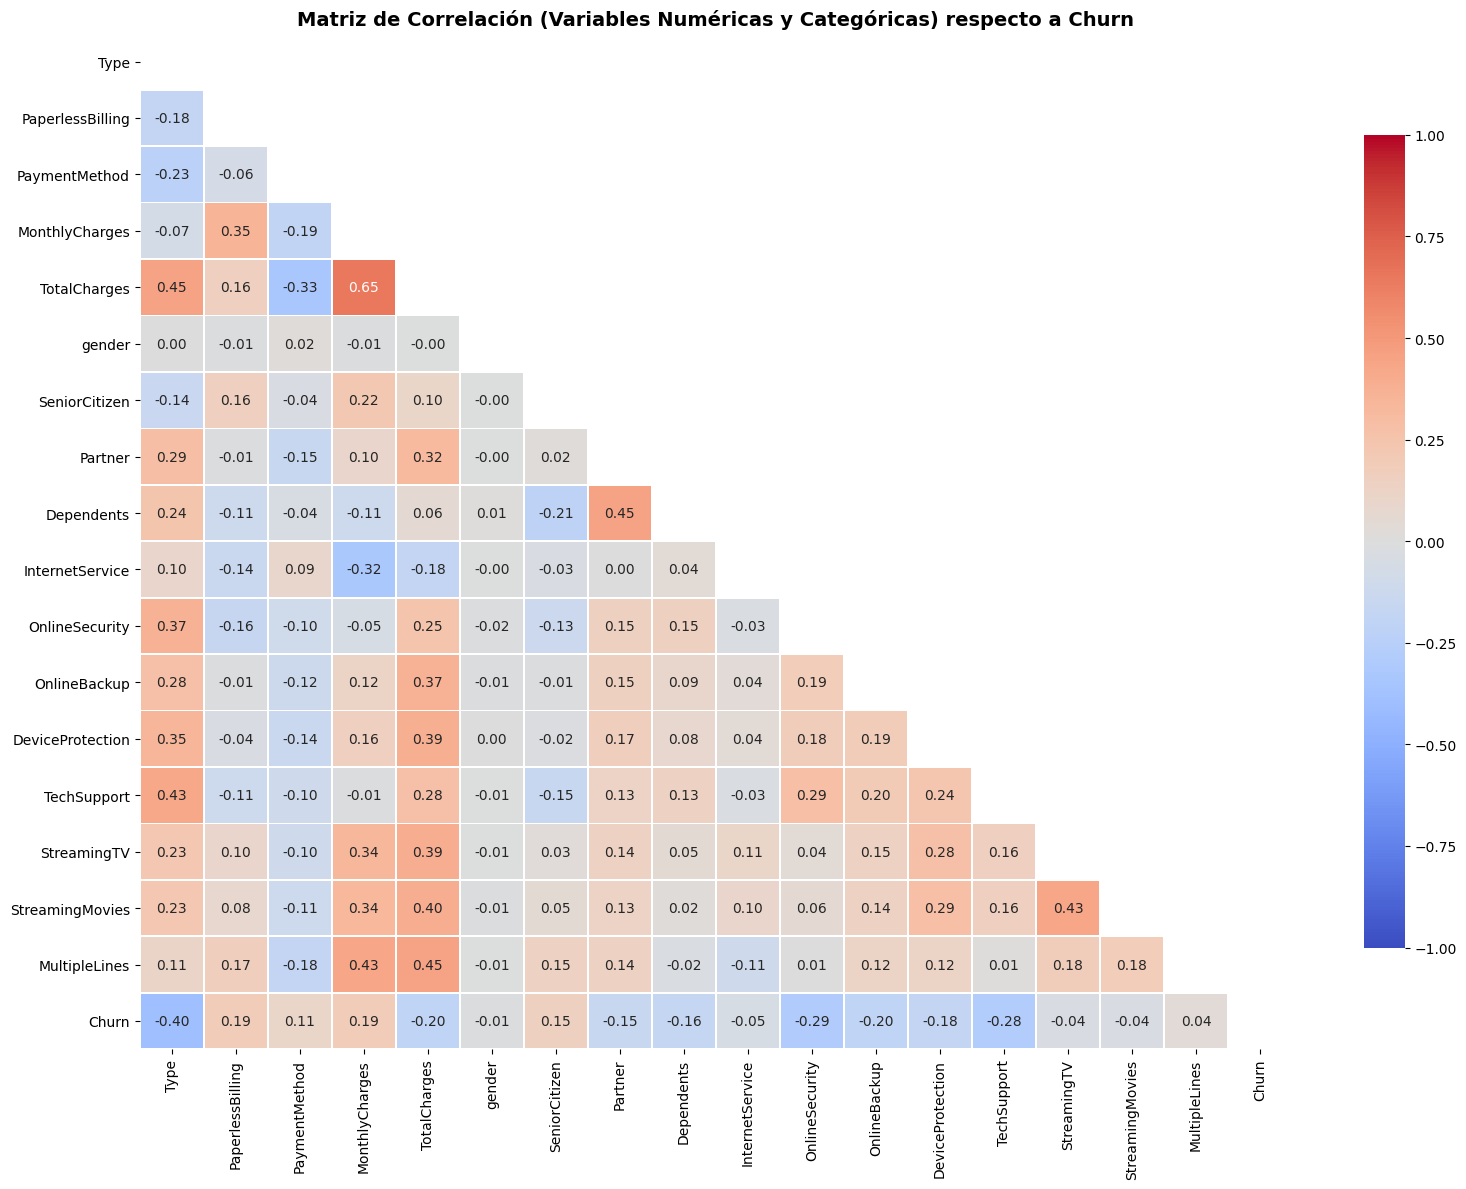

In [15]:
#Crear un HeatMap para detectar correlaciones entre las características disponibles y la variable objetivo
df_corr = df_final.copy()
#Se ignoran los identificadores y las fechas de inicio y fin de contrato
columnas_ignorar = ['customerID', 'BeginDate', 'EndDate']
df_corr = df_corr.drop(columns=[col for col in columnas_ignorar if col in df_corr.columns])

# Se transformam variables categóricas a numéricas. Los casos con NaN se llenan con 'Nulo' y se trata como una clase más y los valores únicos se cambian por valores númericos
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = df_corr[col].fillna('Nulo').astype('category').cat.codes


matriz_correlacion = df_corr.corr()


plt.figure(figsize=(16, 12))

# Máscara para mostrar solo la mitad de la matriz
mask = np.triu(np.ones_like(matriz_correlacion, dtype=bool))


sns.heatmap(
    matriz_correlacion, 
    mask=mask,
    cmap='coolwarm',       
    vmax=1, vmin=-1,       
    center=0, 
    annot=True,            
    fmt=".2f",             
    linewidths=0.5,        
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlación (Variables Numéricas y Categóricas) respecto a Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Gracias al heatmap puede observarse lo siguiente:
* Existe una alta correlación positiva entre los cargos totales y la duración del contrato, aunque esto es una relación espuria ya que es de esperar que cuanto más tiempo permanezca un cliente, más dinero se le cobrará a la larga.
* También hay una correlación positiva moderada de la duración y el tipo de contrato, esto puede deberse también a que los contratos de uno o dos años hacen que dure más por definición su contrato.
* La única correlación a destacar con Churn, es la que existe de forma negativa moderada con el tipo de contrato que como se observó en los graficos de barras de proporciones anteriores es más común el contrato de mes a mes entre los cancelados.

In [16]:
#Resumen estadístico de las variables númericas
resumen_numerico_churn = df_final.groupby('Churn')[['MonthlyCharges', 'TotalCharges']].describe().T
print(resumen_numerico_churn)


Churn                           0            1
MonthlyCharges count  5174.000000  1869.000000
               mean     61.265124    74.441332
               std      31.092648    24.666053
               min      18.250000    18.850000
               25%      25.100000    56.150000
               50%      64.425000    79.650000
               75%      88.400000    94.200000
               max     118.750000   118.350000
TotalCharges   count  5174.000000  1869.000000
               mean   2549.911442  1531.796094
               std    2329.954215  1890.822994
               min       0.000000    18.850000
               25%     572.900000   134.500000
               50%    1679.525000   703.550000
               75%    4262.850000  2331.300000
               max    8672.450000  8684.800000


Aunque las métricas estadísticas no muestran comportamientos inusuales entre las clases, las tendencias descritas anteriormente se observan mejor con las visualizaciones de las distribuciones de los datos.

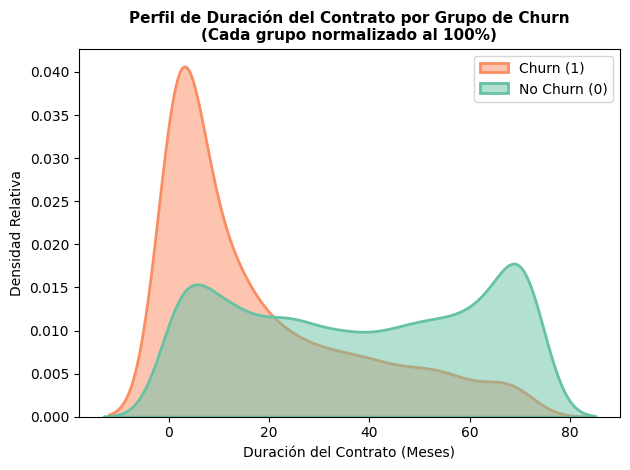

In [17]:
#Convertir a DateTime
df_final['BeginDate'] = pd.to_datetime(df_final['BeginDate'])

# Tomar la última fecha de inicio de contrato como la mayor, esto con el fin de utilizarla como fecha de fin de los casos donde aún no se tiene fecha de cancelación 
fecha_corte = df_final['BeginDate'].max()

# Crear una copia de EndDate reemplazando 'No' por la fecha de corte
end_date_limpia = df_final['EndDate'].replace('No', fecha_corte)
end_date_limpia = pd.to_datetime(end_date_limpia)


# Calculamos los días y dividimos entre 30.44 (promedio de días al mes) 
df_final['duracion_contrato'] = (end_date_limpia - df_final['BeginDate']).dt.days / 30.44
df_final['duracion_contrato'] = df_final['duracion_contrato'].round(1)


# Gráfico de Densidad (KDE) 
sns.kdeplot(
    data=df_final, 
    x='duracion_contrato', 
    hue='Churn', 
    fill=True, 
    common_norm=False, 
    palette=['#66c2a5', '#fc8d62'], 
    alpha=0.5, 
    linewidth=2
)
plt.title('Perfil de Duración del Contrato por Grupo de Churn\n(Cada grupo normalizado al 100%)', fontsize=11, fontweight='bold')
plt.xlabel('Duración del Contrato (Meses)')
plt.ylabel('Densidad Relativa')
plt.legend(['Churn (1)', 'No Churn (0)'], loc='upper right')


plt.tight_layout()
plt.show()


Como se observa en el gráfico, el pico de la fecuencia de la duración del contrato de los cancelados suele ser alredor de los 10 meses y baja conforme aumenta esta duración, mientras que los que se quedan tienen una distribución más uniforme.

#### Variables de mayor interés

Dado el EDA de la sección anterior, y dado que el objetivo del proyecto es predecir si un cliente se queda o se va con el propósito de generar contramedidas para evitar su partida, las variables de mayor interés serían:

* Tipo de contrato: Como se pudo observar, parece haber una mayor tendencia a permanecer entre usaurios con contratos de un año o más que de ser contratos mensuales.
* Duración del contrato: Al parecer el riesgo de cancelación es mayor en contratos menores a 1 año que entre los que llevan más de ese periodo, lo cual puede deberse a la fidelización (o costumbre y normalización) del cliente.
* Cargo mensual: Se observa que suele ser mayor este monto entre los cancelados.
* Número de servicios adicionales contratados: Parece haber una tendencia de menos servicios extra (con excepción del streaming) contratados por parte de los cancelados.
* Método de pago: El método de pago de cheque electrónico paracer ser más común entre cancelados.

### 3.- Hipótesis de modelamiento

Objetivo: Clasificación Binaria (Churn 0/1), predecir si un cliente abandonará la empresa.

Modelos de ML propuestos:

* Regresión Logística
    *  Justificación: Uno de los modelos más comunes para tareas de clasificación. Posee la cualidad de poser calcular los Odd ratios que nos brindarían una explicabilidad y relación de cada característica utilizada para crear el modelo respecto a la variable objetivo, lo cual nos puede brindar información de relevancia para el sector de ventas no solo para detectar perfiles con tendencias a abandonar, sino además qué reforzar para disminuir esta probabilidad de no renovación.
    *  Cumplimiento de supuestos: Requiere codificación categorica, o puede ser nominal si se quiere probar a jerarquizar datos como el tipo de contrato, donde es mejor para la empresa un contrato a largo plazo que uno mes a mes. Además requiere normalización de variables continuas para un mejor desempeño en su entrenamiento.

* Random Forest

    * Justificación: Un modelo de ML robusto debido a la gran cantidad de predictores que puede utilizar. Captura relaciones complejas y no lineales (en comparación a la RL) y es robusto ante overfitting.
    * Cumplimiento de supuestos: Funciona sin problemas con variables categoricas y númericas como las que contiene el conjunto de datos actual.
      

* LightGBM

    * Justificación: Algoritmo con un gran desempeño en cuanto a desempeño y velocidad de entrenamiento (probado en el curso de manera práctica). Debido a su potenciación de árboles permite máximizar el rendiemiento en cuanto a precisión y AUC-ROC.
    * Cumplimiento de supuestos: Permite trabajar con variables categoricas y númericas como en el caso actual.

### 4.- Indicadores clave (KPIs)

Se utilizarían las siguiente métricas para medir el desempeño de los modelos entrenados, todas estas se escogieron por su amplio uso en problemas de clasificación binaria y también fueron vistos en el curso:

* ROC-AUC (Área bajo al curva ROC): Métrica principal que mide la robustez del modelo ante una tarea o conjunto de datos específico, ayudaría a disernir cuál de los modelos implementados es el que ofrece mejor desempeño en términos generales.
* Recall: Permite estimar qué tan bien el modelo detecta los verdaderos clientes que decidieron cancelar sus contratos.
* Precision: Permitirá estimar la proporción de clientes que cancelaron respecto a todos los que el modelo predijo que cancelarían.
* F1-score: Una métrica de balance entre el Recall y Precision que permite estimar qué tan bien se desempeña un modelo en clasificación binaria.

Algunos de los umbrales que se proponen como meta para los modelo entenados son un ROC-AUC > 0.8, ya que es el estándar en múltiples implementaciones de ML; Recall, Precision y F1 score > 0.75, para garantizar que se detecta al menos el 75 % de clientes que se fugan.

### 5.- Diseño experimental

Las estrategias que se implementarán en los modelos porpuestos para alcanzar los umbrales en las métricas propuestas son los siguientes:

* División de datos estratificado: Esto con la finalidad evitar un desbalanceo mayor entre clases y evitar conjuntos de entrenamiento, prueba y validación aún más desbalanceados.
* Monitoreo de la métrica ROC-AUC y F1-score: Debido a que son buenos indicadores cuando el modelo predice mucho una clase por su hegemonía y no por una correcta hipótesis, sobre todo en clasificación binaria.
* Sub y sobre muestreo: En caso de que los desempeños en las métricas sean pobres, se procedería a utilizar conjuntos de datos sub o sobremuestreados con la finalidad de solventar la problematica del desbalanceo de clases. Incluso se podría utilizar SMOTE para crear instancias sintéticas que permitieran mejorar el entrenamiento del modelo.
* Uso de parámetros de los modelos para el desblanceo de clases: Se puede utilizar la regularización de la Regresión Logística.
* Búsqueda de hiperparámetros: Utilizando GridSearch se puede buscar en un rango razonable los parámetros óptimos de los modelos de ML.
* Uso de validación cruzada: Permitirá detectar el modelo con el desempeño general más robusto.
* Uso de semillas aleatorias: Permite la reproducibilidad de los modelos entrenados.

### 6.- Acciones a ejecutar

1. Procesamiento y limpieza de datos (2 h):
    * Tratamiento de valores ausentes, ya sea con algún valor númerico adecuado o una etiqueta.
    * Conversión de las fechas a datos DateTime.
    * Detección y evaluación de los valores atípicos.

2. Preparación de datos (2h):

    * Ingeniería de características, como la creación de las variables Churn y DuracionContrato (que ya se realizaron en el EDA).
    * Codificación: Aplicar One Hot Encoding a las variables categoricas como tipo de contrato y servicios extra de internet.
    * Escalamiento y partición: Estandarizar los valores continuos de variables númericas como cargos totales para el mejor desempeño de la RL, así como la dicisón estratifificada de los datos de entrenamiento, prueba y validación (60/20/20).

3. Desarrollo de modelos (2h):

    * Desarrollo de un modelo base de referencia como cota de desempeño menor, puede ser simplemente prediciendo la clase mayoritaria.
    * Segumiento del diseño experimental descrito anteriormente en cada modelo.
    * Selección del modelo óptimo mediante los conjuntos de prueba y verificación final entrenandolo con los hiperpárametros elegidos y utilizando el conjunto de entrenamiento y prueba para finalmente evaluarlo con el conjunto de validación.

4. Comunicación de resultados (1 día):

    * Cálculo de las características con mayor importancia para la predicción de cancelados, puede ser con el coeficiente informativo del RF, los oods ratios de la RL o incluso utilizando SHAP, con estas se pueden crear gráficos que muestren no solo la importancia de cada característica sino además su posible relación y el por qué de su influencia en que exista o no un cancelado.
    * Basados en las potenciales relaciones detectadas realizar un resumen ejecutivo en Jupyter Notebook y ofreciendo consejos o estrategías para el área de mercadeo basado en los hallazgos de este proyecto.

### 7.- Stakeholders impactados

* Dirección de marketing y estrategia comercial: Es el área responsable de diseñar e implementar campañas de retención de clientes. Puede utilizar tanto las predicicones de clientes con potencial de cancelar para que si pasan un umbral enfocar su atención en ofrecerle incentivos para mantenerse, basadas estas acciones en aquellas características que tienen un mayor peso en la predicción de cancelación y con ello contrarestarlas o ptenciar aquellas que reucen el riesgo.

* Servicio al cliente: Pueden dar prioridad a aquellos clientes con un score de alta probabilidad de deserción y con ello mejorar sus servicios y experiencia rápidamente para no incentivar a su abandono.

* Dirección financiera: Permitiría calcular el porcentaje de clientes con una alta probabilidad de deserción al que se le podrían ofrecer beneficios extra sin que esto merme demasiado las gaanncias de la empresa en comparación a simplemente dejarlos ir.

### Lista de preguntas aclaratorias

Las preguntas son acerca de si las metodologías y métricas propuestas son lo esperable por parte de la empresa:

¿Cómo se mide el éxito de este entregable? ¿Existen métricas clave además de las propuestas?

¿Quién es la audiencia principal de este trabajo (cliente externo, otro equipo interno, dirección)?